In [51]:
from pathlib import Path
import os

import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

from rdkit.Chem import Descriptors
import streamlit as st
from torch_geometric.data import Dataset
from torch_geometric.loader import DataLoader
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

from polynet.app.options.data import DataOptions
from polynet.app.options.state_keys import ExplainModelStateKeys, ProjectionPlotStateKeys
from polynet.app.services.explain_model import analyse_graph_embeddings, explain_model
from polynet.app.services.model_training import load_gnn_model
from polynet.app.utils import extract_number
from polynet.options.col_names import get_predicted_label_column_name, get_true_label_column_name
from polynet.options.enums import (
    DataSets,
    DimensionalityReduction,
    ExplainAlgorithms,
    ImportanceNormalisationMethods,
    ProblemTypes,
    Results,
)

from crystals_experiment.crystal_graph import crystal_graph_dataset

In [52]:
# Set save directory
results_dir = r"Cluster_Analysis"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

In [53]:
model_name = "CGGNN_1.pt"
model_dir = "C:\\Users\\ezxac5\\Documents\\GitHub\\PolyNet\\crystals_experiment\\results\\models"

In [54]:
device="cpu"
path = os.path.join(model_dir, model_name)
model = torch.load(path, weights_only=False, map_location=torch.device('cpu'))

In [55]:
data_options = DataOptions

In [57]:
# get the number of the iteration of the model
iteration = extract_number(model_name)

In [58]:
# Load training/validation/test data
general_dir = Path("crystals_experiment")

targets = pd.read_csv(general_dir / 'data/id_prop.csv', header=None)

dataset = crystal_graph_dataset(
    root= general_dir / "data",
    max_d=3.5,
    step=0.5,
    vor_cut_off=3.5,
    targets=targets
)

In [59]:
# Load tabular features (for PCA feature vectors)
tabular_data_file = r"C:\Users\ezxac5\OneDrive - The University of Nottingham\Tasks\papers\Paper_3\Eduardo\PolyNet_Wright_et_al_LOOCV\Wright_et_al_PolyNet_comps_PCA.csv"
tabular_filename = "Wright_et_al_AL1_PolyNet_comps_PCA"
tabular_data = pd.read_csv(tabular_data_file)
tabular_data = tabular_data.loc[46:66] # Loading Wright et al data
tabular_data.reset_index(inplace=True, drop=True) # Reset data indices

# Create array to store composition names of each datapoint and array to store relevant features and target (for plots)
tabular_data_rel = tabular_data[['Comp', 'RA', 'RB', 'MA', 'MB', 'Entropy_conf', 'TC']]

# Define features and target variable
tabular_data_features = tabular_data[['RA', 'RB', 'MA', 'MB', 'Entropy_conf']]

In [60]:
# Normalize features
#Normalize using MinMaxScaler
tabular_data_features_a = np.array(tabular_data_features)

min_value = np.min(tabular_data_features_a, axis=0)
max_value = np.max(tabular_data_features_a, axis=0)

scaler = MinMaxScaler()

scaler.fit([min_value, max_value])

tabular_data_features_a = scaler.transform(tabular_data_features_a)

# Normalize using standard scaler

scaler2 = StandardScaler()

scaler2.fit(tabular_data_features)

tabular_data_features_ss = scaler2.transform(tabular_data_features)

In [61]:
print(tabular_data_features_ss)

[[ 2.73636436e+00  1.10893251e+00 -1.83998141e+00 -8.64527571e-01
  -2.24565869e+00]
 [ 8.63242013e-02  1.10893251e+00  1.22588912e-02 -8.64527571e-01
  -2.24565869e+00]
 [ 2.73636436e+00  9.09181976e-01 -1.83998141e+00  1.21379622e+00
  -1.36033720e+00]
 [ 8.63242013e-02 -4.39134103e-01  1.22588912e-02 -1.43572453e-02
  -4.75015707e-01]
 [-7.64305973e-01 -4.39134103e-01  1.12639763e+00 -1.43572453e-02
  -4.75015707e-01]
 [-3.38990886e-01 -5.55655259e-01  5.69328263e-01 -1.67370837e-01
   4.28641658e-02]
 [-5.51648429e-01 -5.55655259e-01  6.99014659e-01 -1.67370837e-01
   4.28641658e-02]
 [-5.35290157e-01  5.76264439e-01 -1.67810141e+00  9.57425326e-01
   4.28641658e-02]
 [-5.51648429e-01  5.76264439e-01  6.99014659e-01  9.57425326e-01
   4.28641658e-02]
 [-9.19930049e-04  9.09181976e-01 -1.44441579e+00  1.21379622e+00
   4.28641658e-02]
 [-3.38990886e-01  9.09181976e-01  4.70096064e-01  1.21379622e+00
   4.28641658e-02]
 [-3.38990886e-01  5.76264439e-01  4.70096064e-01  9.57425326e-01

In [62]:
print(tabular_data_features)

          RA        RB          MA          MB  Entropy_conf
0   1.160000  0.720000  138.905470   91.224000      0.171259
1   1.079000  0.720000  150.360000   91.224000      0.171259
2   1.160000  0.715000  138.905470  134.857000      0.801393
3   1.079000  0.681250  150.360000  109.072750      1.431527
4   1.053000  0.681250  157.250000  109.072750      1.431527
5   1.066000  0.678333  153.805000  105.860333      1.800131
6   1.059500  0.678333  154.607000  105.860333      1.800131
7   1.060000  0.706667  139.906560  129.474667      1.800131
8   1.059500  0.706667  154.607000  129.474667      1.800131
9   1.076333  0.715000  141.351707  134.857000      1.800131
10  1.066000  0.715000  153.191333  134.857000      1.800131
11  1.066000  0.706667  153.191333  129.474667      2.168736
12  1.066000  0.681250  153.191333  109.072750      2.430265
13  1.045750  0.681250  158.153500  109.072750      2.691794
14  1.066000  0.655833  153.191333   88.670833      2.299501
15  1.066000  0.630417  

In [63]:
pred_path = r'C:\Users\ezxac5\Documents\GitHub\PolyNet\crystals_experiment\results'
pred_file = os.path.join(pred_path, 'predictions.csv')

In [64]:
preds = pd.read_csv(pred_file)

In [65]:
preds.describe()

,Unnamed: 0,Bootstrap Iteration,True target,GCN Predicted target,GraphSAGE Predicted target,TransformerConvGNN Predicted target,GAT Predicted target,MPNN Predicted target,CGGNN Predicted target
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,14.500000,3.000000,1.981340,1.871503,1.867797,1.932339,1.922240,1.967024,1.938885
std,8.684438,1.418951,0.312987,0.326203,0.332473,0.312602,0.302614,0.292989,0.317118
min,0.000000,1.000000,1.360000,1.242565,0.887338,1.234504,1.211018,1.347398,1.262743
25%,7.000000,2.000000,1.710000,1.560142,1.615683,1.658221,1.672336,1.735917,1.659480
50%,14.500000,3.000000,2.100000,1.961499,1.942987,2.058047,2.006002,2.077632,2.050724
75%,22.000000,4.000000,2.240000,2.164427,2.127104,2.194180,2.154854,2.208679,2.189123
max,29.000000,5.000000,2.290400,2.315485,2.569966,2.283917,2.423288,2.341418,2.360597


In [66]:
# get the name of the predicted col name for the model selected by the user
predicted_col_name = get_predicted_label_column_name(target_variable_name=data_options.target_variable_name, model_name=model._name)

In [67]:
# get the number of the iteration of the model
iteration = extract_number(model_name)
print(iteration)

1


In [68]:
# filter the predictions to get only the predictions of the corresponding iteration and the corresponding model
preds_projection = preds.loc[preds['Bootstrap Iteration'] == iteration, [Results.Set.value, 'GCN Predicted target']]

In [69]:
print(preds_projection)

           Set  GCN Predicted target
0        Train              2.054973
1        Train              1.348325
2        Train              1.823892
3        Train              1.347385
4        Train              1.348551
5        Train              1.476054
6        Train              1.836276
7        Train              1.425391
8        Train              1.457647
9        Train              1.999788
10       Train              2.065383
11       Train              1.768143
12       Train              1.960074
13       Train              1.999695
14       Train              2.142323
15       Train              2.275177
16       Train              1.840641
17       Train              2.301923
18       Train              2.288837
19       Train              1.733558
20       Train              1.525847
21       Train              1.270800
22       Train              1.966527
23       Train              1.974201
24  Validation              2.123911
25  Validation              2.281770
2

In [70]:
def get_graph_embeddings(dataset, model) -> np.ndarray:
    """
    Get graph embeddings for the dataset using the provided model.

    Args:
        dataset (CustomPolymerGraph): The dataset containing graph data.
        model: The model used to generate embeddings.

    Returns:
        np.ndarray: An array of graph embeddings.
    """
    loader = DataLoader(dataset=dataset, batch_size=1, shuffle=False)
    embeddings = []
    idx = []

    for batch in loader:
        with torch.no_grad():
            embedding = model.get_graph_embedding(
                x=batch.x,
                edge_index=batch.edge_index,
                edge_attr=batch.edge_attr,
                batch_index=batch.batch,
                monomer_weight=batch.weight_monomer,
            )
            embeddings.append(embedding.cpu().numpy())
            idx.append(batch.idx)

    idx = np.array(idx).flatten().tolist()
    
    embeddings = pd.DataFrame(np.concatenate(embeddings, axis=0), index=idx)

    return embeddings


In [71]:
def analyse_graph_embeddings(
    model,
    dataset,
    labels: pd.Series,
    style_by: pd.Series,
    mols_to_plot: list,
    reduction_method: str,
    reduction_parameters: dict,
    colormap: str,
):

    embeddings = get_graph_embeddings(dataset, model)

    if reduction_method == DimensionalityReduction.tSNE:
        tsne = TSNE(n_components=2, **reduction_parameters)
        reduced = tsne.fit_transform(embeddings)

    elif reduction_method == DimensionalityReduction.PCA:
        pca = PCA(n_components=2, **reduction_parameters)
        reduced = pca.fit_transform(embeddings)

    reduced_embeddings = pd.DataFrame(reduced, index=embeddings.index, columns=["Dim1", "Dim2"])
    reduced_embeddings = reduced_embeddings.loc[mols_to_plot]
    reduced_embeddings = reduced_embeddings.to_numpy()

    labels = labels.loc[mols_to_plot]

    projection_fig = plot_projection_embeddings(
        reduced_embeddings, labels=labels, cmap=colormap, style=style_by
    )
    st.pyplot(projection_fig, use_container_width=True)

In [72]:
embeddings = get_graph_embeddings(dataset, model)

In [73]:
#analyse_graph_embeddings(model, dataset)

In [74]:
embeddings = embeddings.sort_index(key=lambda idx: idx.str.extract(r'(\d+)').astype(int)[0]) # Sort embeddings by CIF IDs

In [75]:
print(embeddings)

            0           1          2           3          4           5    \
c1     2.503614   -0.265298  -0.568855   93.603348  -0.548451   44.743088   
c2    -0.399259   -0.307557  94.229004   -0.477765  44.452801   -0.528943   
c3     4.391834   -0.256338  -0.572624  112.192474  -0.499542   56.663700   
c4    35.850643   44.479610   2.392344    2.872445  35.140221   22.417604   
c5    66.207291   42.805107  -0.565214   47.748184  21.092627  118.830238   
c6    77.237328   79.733597  -0.224224   11.904148  48.745605   85.492546   
c7    70.278755   40.910347  -0.572824   57.105705  16.761269  138.497635   
c8    -0.218097   -0.261492   5.948438  122.812424   3.312110    6.250665   
c9    11.573630   -0.252955  -0.572770  106.703285  -0.110588   74.923088   
c10   -0.420120   -0.278243  80.660019  100.654243  28.447729   -0.436203   
c11    1.848241   -0.274719   2.593455   87.442825  15.660470   15.299118   
c12    7.694309   -0.264304  -0.529800   87.380051   0.930894   53.417278   

In [76]:
# Normalize embeddings using MinMaxScaler

embeddings_a = np.array(embeddings)

min_value = np.min(embeddings_a, axis=0)
max_value = np.max(embeddings_a, axis=0)

scaler_em = MinMaxScaler()

embeddings_a = scaler_em.fit_transform(embeddings_a)
embeddings_a = pd.DataFrame(embeddings_a, columns=embeddings.columns)

# Normalize using StandardScaler

embeddings_ss = np.array(embeddings)

scaler_em2 = StandardScaler()

embeddings_ss = scaler_em2.fit_transform(embeddings_ss)
embeddings_ss = pd.DataFrame(embeddings_ss, columns=embeddings.columns)

In [77]:
print(embeddings_a)

         0         1             2         3         4         5         6    \
0   0.018560  0.000256  4.186202e-05  0.763377  0.000000  0.216259  0.000239   
1   0.000132  0.000000  9.999999e-01  0.001226  0.517158  0.000000  0.000000   
2   0.030547  0.000311  2.103858e-06  0.913968  0.000562  0.273202  0.000262   
3   0.230253  0.271822  3.127754e-02  0.028366  0.410137  0.109613  0.226242   
4   0.422962  0.261659  8.027116e-05  0.391904  0.248701  0.570165  0.296960   
5   0.492982  0.485785  3.677139e-03  0.101532  0.566491  0.410914  0.486933   
6   0.448808  0.250160  0.000000e+00  0.467710  0.198925  0.664113  0.266940   
7   0.001282  0.000280  6.878835e-02  1.000000  0.044366  0.032385  0.000190   
8   0.076138  0.000331  5.625188e-07  0.869500  0.005032  0.360425  0.000291   
9   0.000000  0.000178  8.568699e-01  0.820497  0.333226  0.000443  0.000112   
10  0.014400  0.000199  3.339892e-02  0.713471  0.186274  0.075609  0.000206   
11  0.051512  0.000263  4.538246e-04  0.

In [78]:
# Calculate principal components using orginal embeddings and normalized sets (both minmax and standardscaler)
## Orginial
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(embeddings)

## MinMaxScaler

pca_mms = PCA(n_components=2, random_state=42)
reduced_mms = pca_mms.fit_transform(embeddings_a)

# StandardScaler

pca_ss = PCA(n_components=2, random_state=42)
reduced_ss = pca_ss.fit_transform(embeddings_ss)

In [79]:
print(embeddings.index)

Index(['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9', 'c10', 'c11',
       'c12', 'c13', 'c14', 'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21'],
      dtype='object')


In [80]:
print(embeddings_ss.index)

RangeIndex(start=0, stop=21, step=1)


In [81]:
tabular_data_features_a = pd.DataFrame(tabular_data_features_a, columns=tabular_data_features.columns)
print(tabular_data_features_a)

          RA        RB        MA        MB  Entropy_conf
0   1.000000  1.000000  0.000000  0.344733      0.000000
1   0.291028  1.000000  0.595101  0.344733      0.000000
2   1.000000  0.944186  0.000000  1.000000      0.227670
3   0.291028  0.567442  0.595101  0.612780      0.455340
4   0.063457  0.567442  0.953060  0.612780      0.455340
5   0.177243  0.534884  0.774081  0.564537      0.588519
6   0.120350  0.534884  0.815747  0.564537      0.588519
7   0.124726  0.851163  0.052010  0.919170      0.588519
8   0.120350  0.851163  0.815747  0.919170      0.588519
9   0.267688  0.944186  0.127090  1.000000      0.588519
10  0.177243  0.944186  0.742199  1.000000      0.588519
11  0.177243  0.851163  0.742199  0.919170      0.721698
12  0.177243  0.567442  0.742199  0.612780      0.816189
13  0.000000  0.567442  1.000000  0.612780      0.910681
14  0.177243  0.283721  0.742199  0.306390      0.768943
15  0.177243  0.000000  0.742199  0.000000      0.635765
16  0.000000  0.330233  1.00000

In [82]:
# Create merged dataframe for plot
# Using original tabular data features for PCA vectors as they are not the same features use for the PCA

## Original embeddings
components_df = pd.DataFrame(data=reduced,\
                            columns=['0', '1'])



plot_df = pd.concat([pd.DataFrame(embeddings.index), tabular_data_rel['Comp'], components_df, targets[1], tabular_data_features], axis=1)
plot_df.columns = ['Id', 'Comp', '0', '1', 'Target TC', 'RA', 'RB', 'MA', 'MB', 'Entropy_conf']

## MinMaxScaler
components_df_mms = pd.DataFrame(data=reduced_mms,\
                            columns=['0', '1'])



plot_df_mms = pd.concat([pd.DataFrame(embeddings.index), tabular_data_rel['Comp'], components_df_mms, targets[1], tabular_data_features], axis=1)
plot_df_mms.columns = ['Id', 'Comp', '0', '1', 'Target TC', 'RA', 'RB', 'MA', 'MB', 'Entropy_conf']

## StandardScaler

components_df_ss = pd.DataFrame(data=reduced_ss,\
                            columns=['0', '1'])



plot_df_ss = pd.concat([pd.DataFrame(embeddings.index), tabular_data_rel['Comp'], components_df_ss, targets[1], tabular_data_features], axis=1)
plot_df_ss.columns = ['Id', 'Comp', '0', '1', 'Target TC', 'RA', 'RB', 'MA', 'MB', 'Entropy_conf']


In [83]:
# Calculate loadings from graph features

loadings = pca.components_.T*np.sqrt(pca.explained_variance_)
loadings_mms = pca_mms.components_.T*np.sqrt(pca_mms.explained_variance_)
loadings_ss = pca_ss.components_.T*np.sqrt(pca_ss.explained_variance_)

In [84]:
# Calculate correlation between tabular features and PC1 and PC2 
# (for generating vectors based on the simplified tabular features)

tabular_feature_names = tabular_data_features.columns
correlations = []

for col in tabular_feature_names:
    corr_pc1 = np.corrcoef(tabular_data_features[col], reduced[:, 0])[0, 1]
    corr_pc2 = np.corrcoef(tabular_data_features[col], reduced[:, 1])[0, 1]
    correlations.append([corr_pc1, corr_pc2])

corr_df = pd.DataFrame(correlations, columns=['PC1', 'PC2'], index=tabular_feature_names)

In [93]:
print(correlations)

[[-0.4741378023150544, 0.014055158070332942], [-0.9028828989009234, -0.34377846885071295], [0.6555338344422912, 0.17304074204539813], [-0.7919248799212647, 0.06676762259174848], [0.1673188883761629, 0.19344578699377846]]


In [94]:
print(corr_df)

                   PC1       PC2
RA           -0.474138  0.014055
RB           -0.902883 -0.343778
MA            0.655534  0.173041
MB           -0.791925  0.066768
Entropy_conf  0.167319  0.193446


In [85]:
# Calculate scaling factor for arrow visibility

scaling_factor = np.max(reduced)*0.8

In [86]:
print(components_df)

             0           1
0  -366.396210  185.791718
1   -24.471138 -650.182556
2  -435.919037  322.882050
3   163.947418 -305.853027
4    45.206409  239.842606
5   328.525696  -76.492378
6    54.314655  308.196899
7  -422.444153   21.965940
8  -427.487061  380.243195
9  -308.601593 -329.241302
10 -251.318359  -95.099258
11 -322.587158  153.428650
12   56.379986   99.253380
13  225.974258   71.384918
14  329.285339  165.533188
15  773.294189  293.538055
16  643.328186   93.943176
17  641.935974 -233.343582
18 -152.180237 -366.633728
19 -236.641006 -270.162659
20 -314.146393   -8.995148


In [87]:
print(plot_df)

     Id                                               Comp           0  \
0    c1                                           La2Zr2O7 -366.396210   
1    c2                                           Sm2Zr2O7  -24.471138   
2    c3                                 La2(Zr1/2Hf1/2)2O7 -435.919037   
3    c4                       Sm2(Zr1/4Hf1/4Sn1/4Ti1/4)2O7  163.947418   
4    c5                       Gd2(Zr1/4Hf1/4Sn1/4Ti1/4)2O7   45.206409   
5    c6                  (Sm1/2Gd1/2)2(Zr1/3Hf1/3Ti1/3)2O7  328.525696   
6    c7                  (Gd1/2Eu1/2)2(Zr1/3Hf1/3Ti1/3)2O7   54.314655   
7    c8                  (La1/2Pr1/2)2(Zr1/3Hf1/3Sn1/3)2O7 -422.444153   
8    c9                  (Gd1/2Eu1/2)2(Zr1/3Hf1/3Sn1/3)2O7 -427.487061   
9   c10                  (La1/3Nd1/3Pr1/3)2(Zr1/2Hf1/2)2O7 -308.601593   
10  c11                  (Sm1/3Gd1/3Eu1/3)2(Zr1/2Hf1/2)2O7 -251.318359   
11  c12             (Sm1/3Gd1/3Eu1/3)2(Zr1/3Hf1/3Sn1/3)2O7 -322.587158   
12  c13        (Sm1/3Gd1/3Eu1/3)2(Zr1/

In [88]:
for i, row in corr_df.iterrows():
    print(row['PC1'])

-0.4741378023150544
-0.9028828989009234
0.6555338344422912
-0.7919248799212647
0.1673188883761629


In [89]:
import plotly.io as pio
pio.templates.default = "plotly"

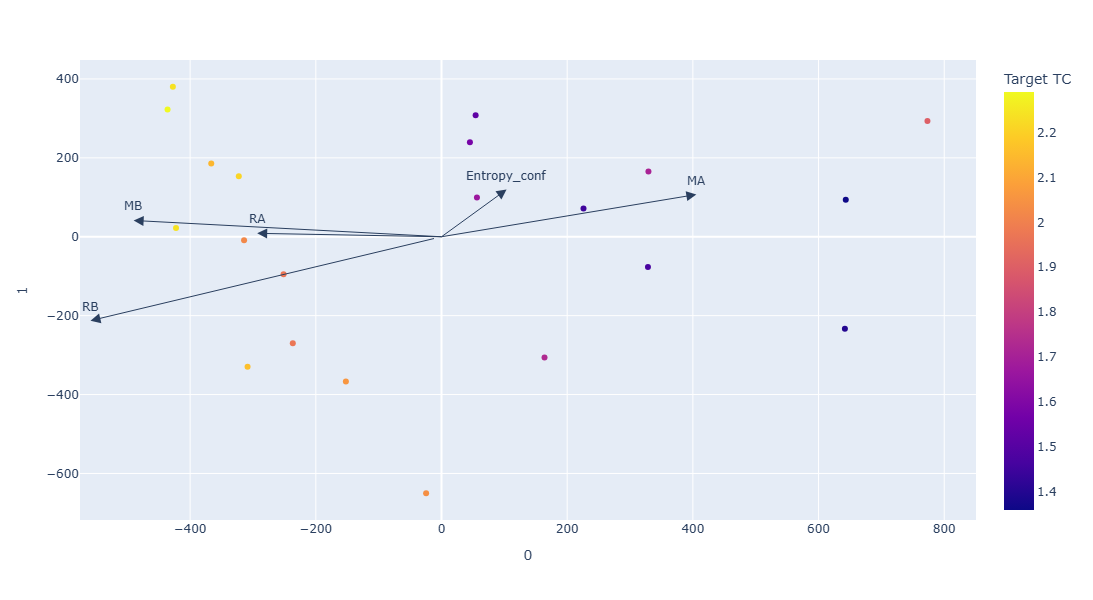

In [90]:
# Generate PCA plot
fig = px.scatter(plot_df, x='0', y='1', color='Target TC', hover_name='Comp', hover_data=['RA', 'RB', 'MA', 'MB', 'Entropy_conf', 'Target TC'])

for feature, corr_val in corr_df.iterrows():
    fig.add_annotation(
        ax=0, ay=0,
        axref="x", ayref="y",
        x=corr_val['PC1']*scaling_factor,
        y=corr_val['PC2']*scaling_factor,
        showarrow=True,
        arrowsize=2,
        arrowhead=2,
        xanchor="right",
        yanchor="top"
    )
    fig.add_annotation(
        x=corr_val['PC1']*scaling_factor,
        y=corr_val['PC2']*scaling_factor,
        ax=0, ay=0,
        xanchor="center",
        yanchor="bottom",
        text=feature,
        yshift=5
    )

fig.update_layout(
    width=800, height=600
)

fig.show()
#fig.write_html(results_dir + '\\' + f"{filename}_PCA-plot.html")

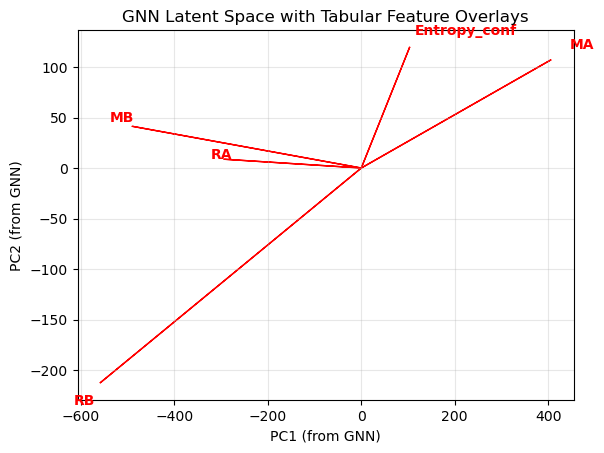

In [91]:
for i, row in corr_df.iterrows():
    plt.arrow(0, 0, row['PC1'] * scaling_factor, row['PC2'] * scaling_factor, 
              color='red', width=0.05, head_width=0.2)
    plt.text(row['PC1'] * scaling_factor * 1.1, row['PC2'] * scaling_factor * 1.1, 
             i, color='red', fontweight='bold')

plt.xlabel('PC1 (from GNN)')
plt.ylabel('PC2 (from GNN)')
plt.title('GNN Latent Space with Tabular Feature Overlays')
plt.grid(alpha=0.3)
plt.show()

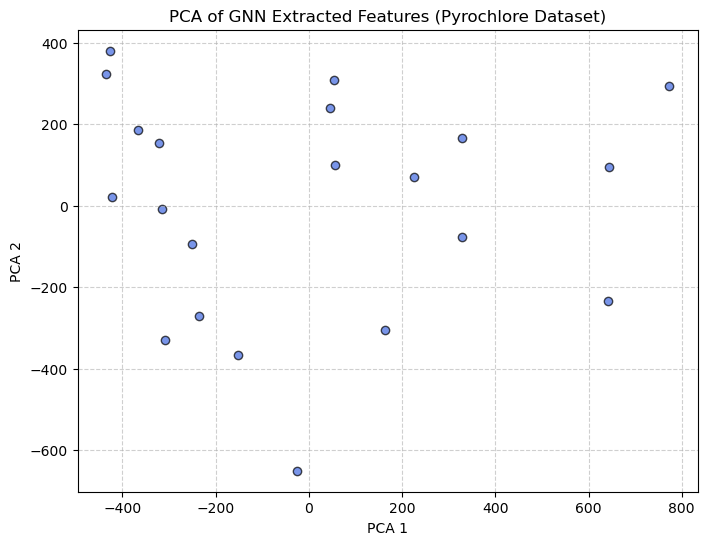

In [92]:
plt.figure(figsize=(8, 6))
plt.scatter(plot_df["0"], plot_df["1"], c='royalblue', edgecolors='k', alpha=0.7)
plt.xlabel(f'PCA 1')
plt.ylabel(f'PCA 2')
plt.title('PCA of GNN Extracted Features (Pyrochlore Dataset)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()